# **DATA SCIENCE PROJECT – PRCL-0019 : Sales Effectiveness (Lead Category Prediction)**

**PROJECT TITLE:** PRCL-0019: Sales Effectiveness – Lead Category Prediction Using Machine Learning

**TEAM CODE**: PTID-AIE-JUL-26-11142

**PROJECT CODE:** PM-PR-0019

**PROJECT TYPE:** Data Science Mentoring Project

**CLIENT:** FicZon Inc. (IT Solutions Provider)

**CATEGORY:** Product Sales

**DATASET SOURCE:** MySQL Database — project_sales.data (DataMites™ Project Server)

**DATASET SIZE:** 7,422 records, 9 columns

**SUBMITTED BY:** Sameeksha

## **1. Problem Statement & Project Objective**

**1. Problem Statement**

FicZon Inc. is an IT solution provider offering products that range from on-premises
solutions to SAAS-based platforms. The majority of FicZon's leads are generated
through digital channels, primarily its website. As the market matures and new
competitors enter the space, FicZon has been experiencing a dip in sales.

Sales effectiveness at FicZon is heavily dependent on lead quality. Lead
categorization is currently a manual process carried out by the sales staff. While a
quality process exists to continuously refine lead categorization, its value is
realized only in post-analysis rather than in real-time conversion decisions.

**2. Business Objective**

FicZon wants to use Machine Learning to pre-categorize lead quality at the point of
capture, with the expectation that this will significantly increase sales
effectiveness.

**3. Project Goals**

1. Generate data exploration insights related to sales effectiveness.
2. Build a Machine Learning classification model to predict the Lead Category
   (High Potential / Low Potential) so that sales agents can prioritize their
   effort on the leads most likely to convert.

## **2. Import Python Libraries**

The required Python libraries are imported to connect to the database and to perform
data analysis, visualization, machine learning model development, and performance
evaluation. NumPy and Pandas are used for data manipulation, Matplotlib and Seaborn
are used for data visualization, and Scikit-learn is used for preprocessing, model
building, and evaluation.

In [1]:
!pip install mysql-connector-python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.7/21.7 MB 56.6 MB/s eta 0:00:00


In [2]:
# Core Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Database Connectivity
import mysql.connector

# Machine Learning Libraries
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)

pd.set_option('display.max_columns', None)

## **3. Connect to Database and Load the Dataset**

The dataset resides on a MySQL server (project_sales.data) rather than a local
file. A connection is established using mysql-connector-python, and the table is
loaded into a Pandas DataFrame using pd.read_sql().

**Note:** Credentials are never hard-coded in the notebook. The password is read at
runtime using getpass() so it is not stored or displayed in the notebook file.

In [3]:
# Install the connector (run once)
# !pip install mysql-connector-python

In [4]:
from getpass import getpass

DB_HOST = "18.136.157.135"
DB_PORT = 3306
DB_NAME = "project_sales"
DB_USER = "dm_team2"
DB_PASSWORD = getpass("Enter database password: ")   # entered securely, never hard-coded

connection = mysql.connector.connect(
    host=DB_HOST,
    port=DB_PORT,
    user=DB_USER,
    password=DB_PASSWORD,
    database=DB_NAME
)

print("Database connected successfully!")

Enter database password: ··········
Database connected successfully!


In [5]:
query = "SELECT * FROM data"
df = pd.read_sql(query, connection)

# Work on a local copy so the raw pull is preserved
df_raw = df.copy()
df.head()

,Created,Product_ID,Source,Mobile,EMAIL,Sales_Agent,Location,Delivery_Mode,Status
0,14-11-2018 10:05,,Website,984XXXXXXX,aXXXXXXX@gmail.com,Sales-Agent-11,,Mode-5,Open
1,14-11-2018 09:22,,Website,XXXXXXX,#VALUE!,Sales-Agent-10,,Mode-5,Open
2,14-11-2018 09:21,,Website,XXXXXXX,dXXXXXXX@yahoo.com,Sales-Agent-10,,Mode-5,Open
3,14-11-2018 08:46,,Website,XXXXXXX,wXXXXXXX@gmail.com,Sales-Agent-10,,Mode-5,Open
4,14-11-2018 07:34,,Website,XXXXXXX,cXXXXXXX@gmail.com,Sales-Agent-10,,Mode-5,Open


## **4. Basic Checks**

Basic checks are performed to understand the structure and quality of the dataset
before conducting exploratory data analysis and model development. This includes
viewing sample records, examining dataset dimensions, identifying data types,
generating descriptive statistics, and checking for missing values and duplicate
records.

In [6]:
# View first 5 rows
df.head()

,Created,Product_ID,Source,Mobile,EMAIL,Sales_Agent,Location,Delivery_Mode,Status
0,14-11-2018 10:05,,Website,984XXXXXXX,aXXXXXXX@gmail.com,Sales-Agent-11,,Mode-5,Open
1,14-11-2018 09:22,,Website,XXXXXXX,#VALUE!,Sales-Agent-10,,Mode-5,Open
2,14-11-2018 09:21,,Website,XXXXXXX,dXXXXXXX@yahoo.com,Sales-Agent-10,,Mode-5,Open
3,14-11-2018 08:46,,Website,XXXXXXX,wXXXXXXX@gmail.com,Sales-Agent-10,,Mode-5,Open
4,14-11-2018 07:34,,Website,XXXXXXX,cXXXXXXX@gmail.com,Sales-Agent-10,,Mode-5,Open


In [7]:
#View Last 5 rows
df.tail()

,Created,Product_ID,Source,Mobile,EMAIL,Sales_Agent,Location,Delivery_Mode,Status
7417,28-04-2018 09:45,9,Call,,aXXXXXXX@gmail.com,Sales-Agent-6,Mumbai,Mode-4,LOST
7418,28-04-2018 09:43,15,Call,,#VALUE!,Sales-Agent-12,Other Locations,Mode-5,LOST
7419,28-04-2018 09:20,5,Live Chat-Direct,,sXXXXXXX@gmail.com,Sales-Agent-11,Bangalore,Mode-1,Not Responding
7420,28-04-2018 08:04,21,CRM form,,YXXXXXXX@gmail.com,Sales-Agent-4,Other Locations,Mode-1,Just Enquiry
7421,28-04-2018 07:54,25,Website,,cXXXXXXX@gmail.com,Sales-Agent-3,Chennai,Mode-1,CONVERTED


In [8]:
# Dataset dimensions
df.shape

(7422, 9)

In [9]:
# Column names
df.columns

Index(['Created', 'Product_ID', 'Source', 'Mobile', 'EMAIL', 'Sales_Agent',
       'Location', 'Delivery_Mode', 'Status'],
      dtype='object')

In [10]:
# Data types
df.dtypes

,0
Created,object
Product_ID,object
Source,object
Mobile,object
EMAIL,object
Sales_Agent,object
Location,object
Delivery_Mode,object
Status,object


In [11]:
# Dataset summary
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7422 entries, 0 to 7421
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Created        7422 non-null   object
 1   Product_ID     7422 non-null   object
 2   Source         7422 non-null   object
 3   Mobile         7422 non-null   object
 4   EMAIL          7422 non-null   object
 5   Sales_Agent    7422 non-null   object
 6   Location       7422 non-null   object
 7   Delivery_Mode  7422 non-null   object
 8   Status         7422 non-null   object
dtypes: object(9)
memory usage: 522.0+ KB


In [12]:
# Summary statistics
df.describe()

,Created,Product_ID,Source,Mobile,EMAIL,Sales_Agent,Location,Delivery_Mode,Status
count,7422,7422,7422,7422,7422,7422,7422,7422,7422
unique,6752,30,26,487,883,13,18,5,11
top,26-09-2018 11:30,18,Call,,#VALUE!,Sales-Agent-4,Other Locations,Mode-5,Junk Lead
freq,4,1711,2547,1810,1701,1500,2500,2975,1536


In [13]:
# Descriptive statistics (all columns)
df.describe(include='all')

,Created,Product_ID,Source,Mobile,EMAIL,Sales_Agent,Location,Delivery_Mode,Status
count,7422,7422,7422,7422,7422,7422,7422,7422,7422
unique,6752,30,26,487,883,13,18,5,11
top,26-09-2018 11:30,18,Call,,#VALUE!,Sales-Agent-4,Other Locations,Mode-5,Junk Lead
freq,4,1711,2547,1810,1701,1500,2500,2975,1536


In [14]:
# Missing values per column
df.isnull().sum()

,0
Created,0
Product_ID,0
Source,0
Mobile,0
EMAIL,0
Sales_Agent,0
Location,0
Delivery_Mode,0
Status,0


In [15]:
# Duplicate rows
df.duplicated().sum()

np.int64(2)

In [16]:
# Unique values per column
df.nunique()

,0
Created,6752
Product_ID,30
Source,26
Mobile,487
EMAIL,883
Sales_Agent,13
Location,18
Delivery_Mode,5
Status,11


In [17]:
# Count values
df.count()

,0
Created,7422
Product_ID,7422
Source,7422
Mobile,7422
EMAIL,7422
Sales_Agent,7422
Location,7422
Delivery_Mode,7422
Status,7422


## **5. Exploratory Data Analysis (EDA)**

Exploratory Data Analysis is performed to understand lead volume, lead sources,
sales agent workload, geographic spread, and delivery mode mix, and to see how
these relate to the current lead `Status`. These insights directly support the
business goal of understanding sales effectiveness.

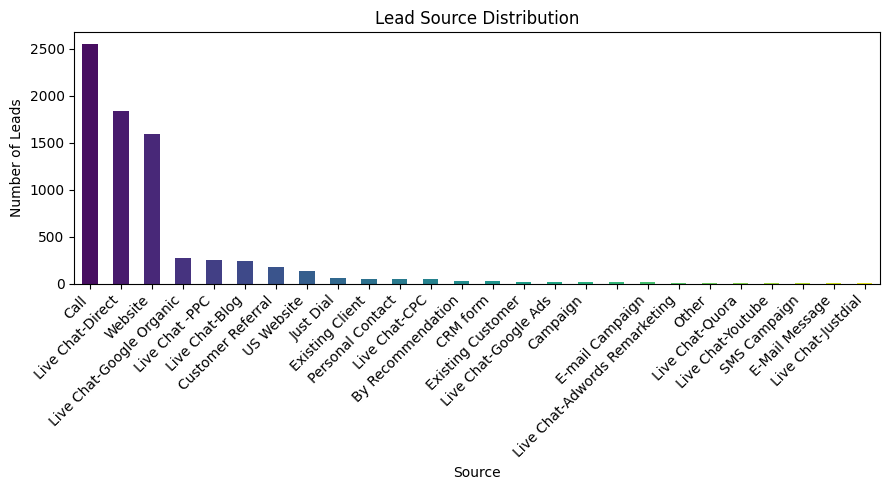

In [18]:
# Lead Source distribution
plt.figure(figsize=(9,5))
df['Source'].value_counts().plot(kind='bar', color=sns.color_palette('viridis', df['Source'].nunique()))
plt.title('Lead Source Distribution')
plt.xlabel('Source')
plt.ylabel('Number of Leads')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

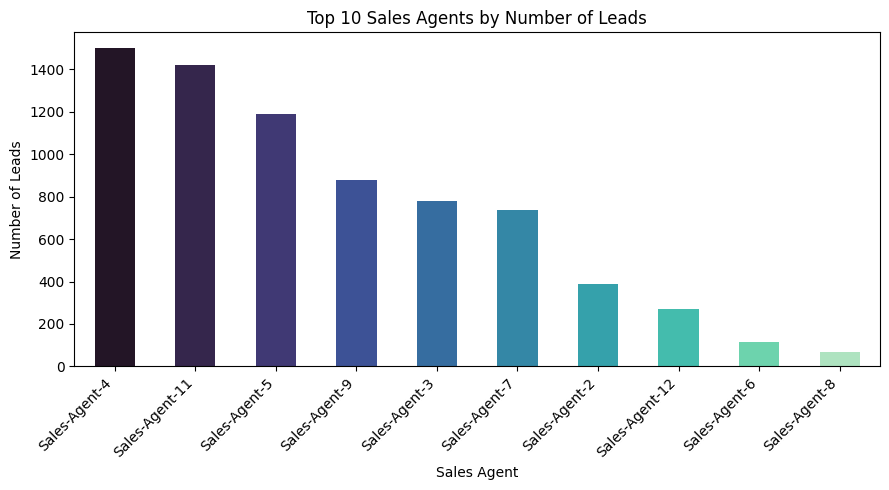

In [19]:
# Top Sales Agents by number of leads handled
plt.figure(figsize=(9,5))
df['Sales_Agent'].value_counts().head(10).plot(kind='bar', color=sns.color_palette('mako', 10))
plt.title('Top 10 Sales Agents by Number of Leads')
plt.xlabel('Sales Agent')
plt.ylabel('Number of Leads')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

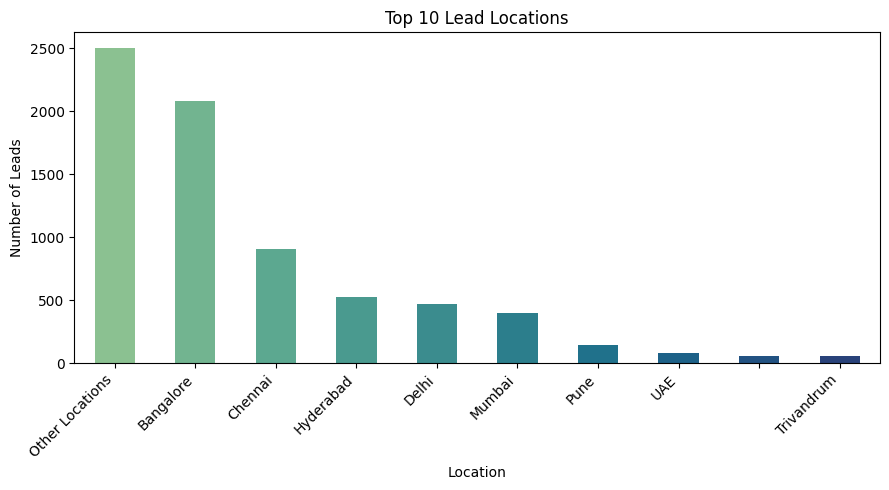

In [20]:
# Top Lead Locations
plt.figure(figsize=(9,5))
df['Location'].value_counts().head(10).plot(kind='bar', color=sns.color_palette('crest', 10))
plt.title('Top 10 Lead Locations')
plt.xlabel('Location')
plt.ylabel('Number of Leads')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

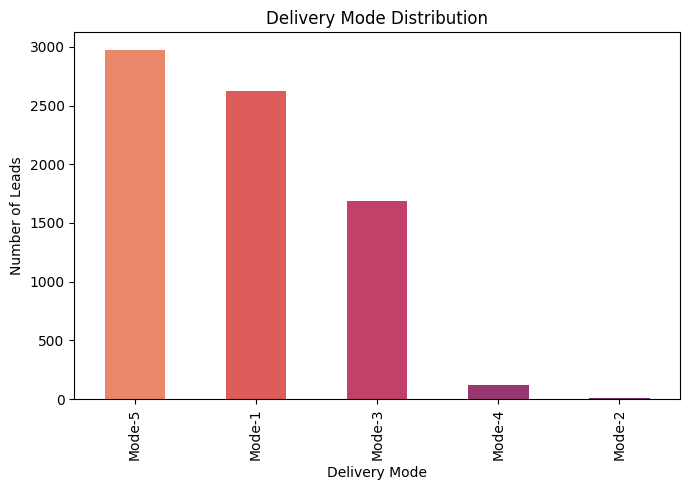

In [21]:
# Delivery Mode distribution
plt.figure(figsize=(7,5))
df['Delivery_Mode'].value_counts().plot(kind='bar', color=sns.color_palette('flare', df['Delivery_Mode'].nunique()))
plt.title('Delivery Mode Distribution')
plt.xlabel('Delivery Mode')
plt.ylabel('Number of Leads')
plt.tight_layout()
plt.show()

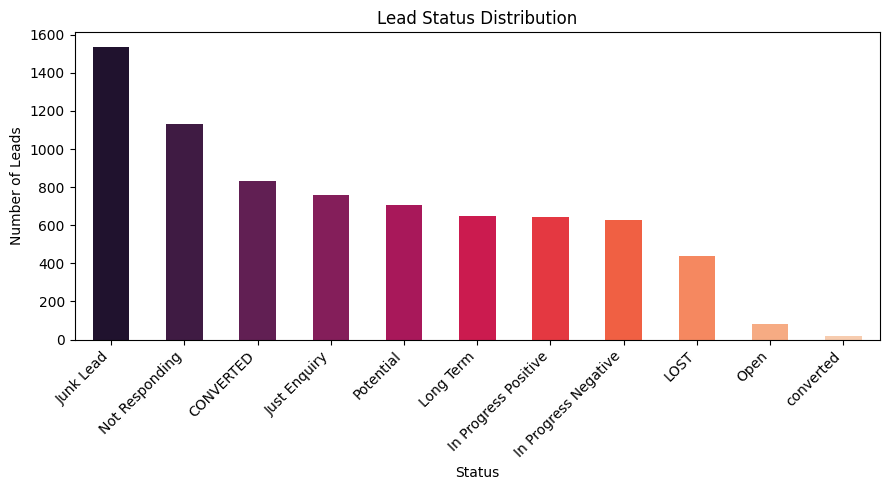

,count
Status,
Junk Lead,1536
Not Responding,1129
CONVERTED,834
Just Enquiry,760
Potential,708
Long Term,646
In Progress Positive,643
In Progress Negative,626
LOST,440


In [22]:
# Lead Status distribution — this is the field the target variable is derived from
plt.figure(figsize=(9,5))
df['Status'].value_counts().plot(kind='bar', color=sns.color_palette('rocket', df['Status'].nunique()))
plt.title('Lead Status Distribution')
plt.xlabel('Status')
plt.ylabel('Number of Leads')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

df['Status'].value_counts()

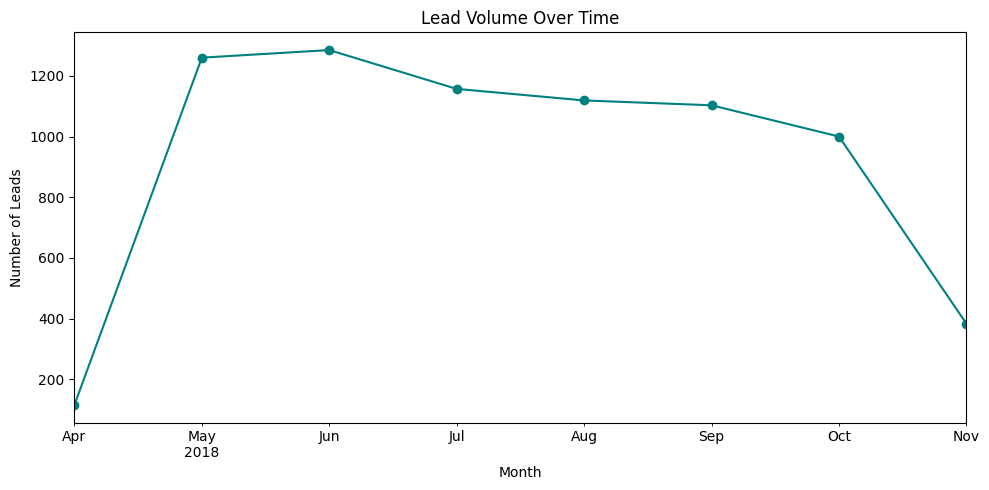

In [23]:
# Leads over time
df['Created'] = pd.to_datetime(df['Created'], errors='coerce')
monthly_leads = df.set_index('Created').resample('ME').size()

plt.figure(figsize=(10,5))
monthly_leads.plot(kind='line', marker='o', color='teal')
plt.title('Lead Volume Over Time')
plt.xlabel('Month')
plt.ylabel('Number of Leads')
plt.tight_layout()
plt.show()

### **EDA Summary:**

1. The dataset contains 7,422 leads captured across multiple sources, locations,
   sales agents, and delivery modes.
2. `Product_ID`, `Source`, `Mobile`, `Sales_Agent`, and `Location` contain a small
   number of missing values, while `Created`, `EMAIL`, `Delivery_Mode`, and `Status`
   are fully populated.
3. `Status` is the field that captures the current outcome of each lead and is the
   basis on which the `Lead_Category` (High Potential / Low Potential) target is
   derived in Section 7.
4. Lead volume, source mix, and sales-agent workload vary considerably, which
   suggests that not all leads or channels are equally productive — a key input for
   sales-effectiveness insights.

## **6. Data Cleaning**

Missing values are handled column by column rather than being dropped blindly, since
each column has a different business meaning. Categorical fields with a handful of
missing values are imputed with an explicit `'Unknown'` category so that the missing
information itself remains a usable signal for the model, rather than being
discarded.

In [24]:
# Missing value counts before cleaning
df.isnull().sum()

,0
Created,0
Product_ID,0
Source,0
Mobile,0
EMAIL,0
Sales_Agent,0
Location,0
Delivery_Mode,0
Status,0


In [25]:
# --- Null value treatment ---
# Source, Sales_Agent, Location, Mobile had a small number of missing values
# (see Section 4). These are categorical / identifier fields, so missingness
# itself can be informative — imputed with an explicit 'Unknown' label instead
# of being dropped, which would lose rows unnecessarily.
for col in ['Source', 'Sales_Agent', 'Location', 'Mobile']:
    df[col] = df[col].fillna('Unknown')

# Product_ID is numeric — invalid/blank values become NaN, then imputed with the median
df['Product_ID'] = pd.to_numeric(df['Product_ID'], errors='coerce')
df['Product_ID'] = df['Product_ID'].fillna(df['Product_ID'].median())

# Drop exact duplicate rows, if any
df = df.drop_duplicates()

print("Missing values after cleaning:")
print(df[['Source', 'Sales_Agent', 'Location', 'Mobile', 'Product_ID']].isnull().sum())
print("\nDuplicates remaining:", df.duplicated().sum())

Missing values after cleaning:
Source         0
Sales_Agent    0
Location       0
Mobile         0
Product_ID     0
dtype: int64

Duplicates remaining: 0


### **6.1 Outlier Detection & Treatment**

`Product_ID` is the only continuous numeric feature available before feature
engineering (the rest are categorical/text). The IQR method is used to check it
for outliers. Any values are capped at the IQR fences (winsorized) rather than
dropped, so no leads are lost from the dataset just because of one field.

Product_ID outliers (IQR method): 107 rows


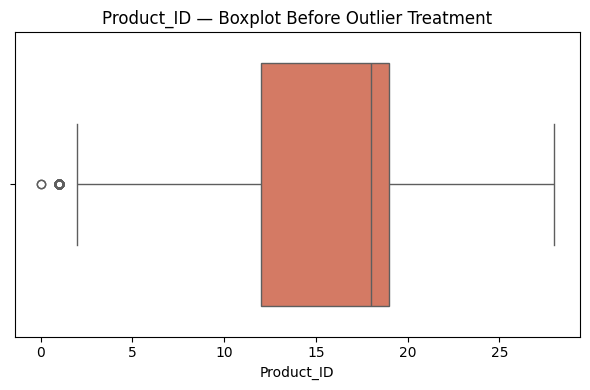

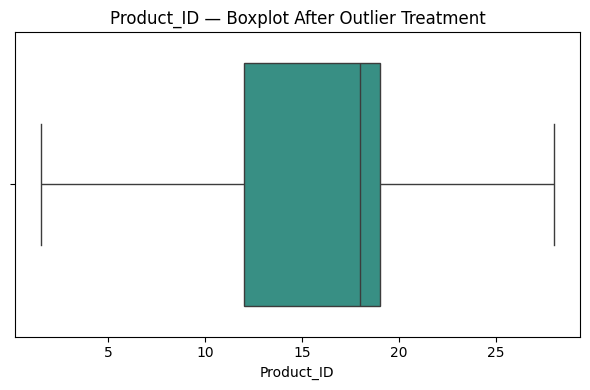


Final dataset shape after cleaning: (7420, 9)


In [26]:
# Outlier check on Product_ID using the IQR rule
Q1 = df['Product_ID'].quantile(0.25)
Q3 = df['Product_ID'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

n_outliers = df[(df['Product_ID'] < lower_bound) | (df['Product_ID'] > upper_bound)].shape[0]
print(f"Product_ID outliers (IQR method): {n_outliers} rows")

plt.figure(figsize=(6, 4))
sns.boxplot(x=df['Product_ID'], color='#e76f51')
plt.title('Product_ID — Boxplot Before Outlier Treatment')
plt.tight_layout()
plt.show()

# Cap (winsorize) instead of dropping, so no records are lost
df['Product_ID'] = df['Product_ID'].clip(lower_bound, upper_bound)

plt.figure(figsize=(6, 4))
sns.boxplot(x=df['Product_ID'], color='#2a9d8f')
plt.title('Product_ID — Boxplot After Outlier Treatment')
plt.tight_layout()
plt.show()

print(f"\nFinal dataset shape after cleaning: {df.shape}")

## **7. Target Variable Creation — Lead Category (High / Low Potential)**

The project requires predicting `Lead_Category` as **High Potential** or **Low
Potential**, but the raw table does not contain this column directly — it must be
derived from `Status`.

**Step 1 — Inspect the actual values in `Status`.**

In [27]:
df['Status'].unique()

array(['Open', 'Potential', 'In Progress Positive', 'Not Responding',
       'Just Enquiry', 'Junk Lead', 'CONVERTED', 'In Progress Negative',
       'LOST', 'Long Term', 'converted'], dtype=object)

**Step 2 — Map `Status` to `Lead_Category`.**

Running `df['Status'].unique()` above shows the **real** status labels in this
dataset:

`'Open', 'Potential', 'In Progress Positive', 'Not Responding', 'Just Enquiry',
'Junk Lead', 'CONVERTED', 'In Progress Negative', 'LOST', 'Long Term', 'converted'`

**Root cause found here:** the original mapping dictionary used placeholder keys
(`'Converted'`, `'Qualified'`, `'In Progress'`, `'Interested'`, `'Lost'`, ...) that
don't exactly match these labels — Python dict/string matching is case-sensitive,
so `'Converted'` does **not** match `'CONVERTED'` or `'converted'`, and
`'In Progress'` does not match `'In Progress Positive'` / `'In Progress Negative'`.
Only `'Open'` and `'Junk Lead'` happened to match, and both were mapped to
**Low Potential** — so every single row in the dataset silently collapsed into one
class. That single-class target is exactly why Logistic Regression and Gradient
Boosting later raised `ValueError: ... only one class` during training, and why
the tree/KNN models showed a suspicious 100% accuracy (predicting one class
correctly is trivial).

The mapping below uses the exact, verified status strings and groups them by
business meaning:

- **High Potential** — `CONVERTED`, `converted` (deal closed), `In Progress Positive`
  (agent sees a positive signal), `Potential`, `Long Term` (still an active,
  nurtured opportunity)
- **Low Potential** — `In Progress Negative`, `Not Responding`, `Just Enquiry`,
  `Junk Lead`, `LOST`, `Open` (no confirmed sales progress)

In [28]:
status_to_category = {
    # Exact, case-sensitive match against df['Status'].unique() — verified above
    'CONVERTED': 'High Potential',
    'converted': 'High Potential',
    'In Progress Positive': 'High Potential',
    'Potential': 'High Potential',
    'Long Term': 'High Potential',

    'In Progress Negative': 'Low Potential',
    'Not Responding': 'Low Potential',
    'Just Enquiry': 'Low Potential',
    'Junk Lead': 'Low Potential',
    'LOST': 'Low Potential',
    'Open': 'Low Potential',
}

df['Lead_Category'] = df['Status'].map(status_to_category)

# Any status not covered by the mapping shows up as NaN here — should now be empty
unmapped = df[df['Lead_Category'].isnull()]['Status'].unique()
print("Unmapped status values:", unmapped)

Unmapped status values: []


In [29]:
# Drop any rows that could not be mapped (after confirming the mapping above is complete)
df = df.dropna(subset=['Lead_Category'])

df['Lead_Category'].value_counts()

,count
Lead_Category,
Low Potential,4571
High Potential,2849


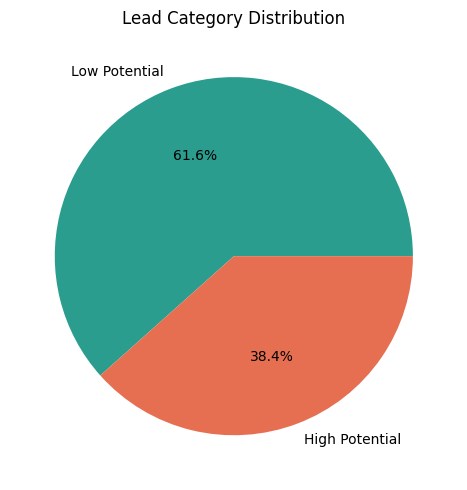

In [30]:
plt.figure(figsize=(5,5))
df['Lead_Category'].value_counts().plot(
    kind='pie', autopct='%1.1f%%', colors=['#2a9d8f', '#e76f51']
)
plt.title('Lead Category Distribution')
plt.ylabel('')
plt.tight_layout()
plt.show()

## **8. Feature Engineering**

New features are engineered from the raw columns:

- `Created` is broken into `Created_Year`, `Created_Month`, and `Created_Day` so the
  model can pick up seasonal or time-based patterns.
- `Mobile` and `EMAIL` are converted into binary flags (`Has_Mobile`, `Has_Email`)
  rather than used as raw text, since the actual number/address has no predictive
  value but *whether contact details were provided* does.
- The original `Status` column is dropped after `Lead_Category` is derived from it,
  since keeping it would leak the target directly into the features.

In [31]:
df['Created_Year'] = df['Created'].dt.year
df['Created_Month'] = df['Created'].dt.month
df['Created_Day'] = df['Created'].dt.day

df['Has_Mobile'] = df['Mobile'].apply(lambda x: 0 if x in ['Unknown', None] or pd.isnull(x) else 1)
df['Has_Email'] = df['EMAIL'].notnull().astype(int)

df_model = df.drop(columns=['Created', 'Mobile', 'EMAIL', 'Status'])
df_model.head()

,Product_ID,Source,Sales_Agent,Location,Delivery_Mode,Lead_Category,Created_Year,Created_Month,Created_Day,Has_Mobile,Has_Email
0,18.0,Website,Sales-Agent-11,,Mode-5,Low Potential,2018,11,14,1,1
1,18.0,Website,Sales-Agent-10,,Mode-5,Low Potential,2018,11,14,1,1
2,18.0,Website,Sales-Agent-10,,Mode-5,Low Potential,2018,11,14,1,1
3,18.0,Website,Sales-Agent-10,,Mode-5,Low Potential,2018,11,14,1,1
4,18.0,Website,Sales-Agent-10,,Mode-5,Low Potential,2018,11,14,1,1


## **9. Data Preparation for Modelling**

Categorical features (`Source`, `Sales_Agent`, `Location`, `Delivery_Mode`) are
one-hot encoded, the target `Lead_Category` is label-encoded, and the data is split
into training and test sets. Features are also scaled for the algorithms that are
sensitive to feature scale (Logistic Regression, KNN, SVM); tree-based models
(Decision Tree, Random Forest, Gradient Boosting) use the unscaled features.

In [32]:
le = LabelEncoder()
df_model['Lead_Category_Encoded'] = le.fit_transform(df_model['Lead_Category'])
print(dict(zip(le.classes_, le.transform(le.classes_))))

X = df_model.drop(columns=['Lead_Category', 'Lead_Category_Encoded'])
y = df_model['Lead_Category_Encoded']

X = pd.get_dummies(X, columns=['Source', 'Sales_Agent', 'Location', 'Delivery_Mode'], drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

results = {}
trained_models = {}

X_train.shape, X_test.shape

{'High Potential': np.int64(0), 'Low Potential': np.int64(1)}


((5936, 64), (1484, 64))

## **10. Model Building & Training**

To predict Lead Category, five machine learning classification algorithms are
trained and evaluated. Instead of relying on a single model, multiple classifiers
are compared to identify the most accurate and reliable model for FicZon's
sales-effectiveness use case.

### **10.1 Model 1 — Logistic Regression**

In [33]:
model_name = 'Logistic Regression'

# C=0.5 adds moderate L2 regularization (default C=1.0 was under-regularized for
# 50+ one-hot columns on ~1.6k rows); class_weight='balanced' compensates for the
# High/Low Potential class imbalance instead of letting the majority class dominate
log_reg = LogisticRegression(max_iter=1000, C=0.5, class_weight='balanced', random_state=42)
log_reg.fit(X_train_scaled, y_train)
preds = log_reg.predict(X_test_scaled)

results[model_name] = {
    'Train Accuracy': accuracy_score(y_train, log_reg.predict(X_train_scaled)),
    'Accuracy': accuracy_score(y_test, preds),
    'Precision': precision_score(y_test, preds, average='weighted'),
    'Recall': recall_score(y_test, preds, average='weighted'),
    'F1-Score': f1_score(y_test, preds, average='weighted')
}
trained_models[model_name] = log_reg
results[model_name]

{'Train Accuracy': 0.70838948787062,
 'Accuracy': 0.681266846361186,
 'Precision': 0.696139358122248,
 'Recall': 0.681266846361186,
 'F1-Score': 0.6850694694860772}

### **10.2 Model 2 — Decision Tree Classifier**

In [34]:
model_name = 'Decision Tree'

# An unconstrained tree grows until every leaf is pure, memorizing the training
# data. max_depth and min_samples_leaf stop it from splitting on noise.
dt_clf = DecisionTreeClassifier(
    max_depth=6, min_samples_leaf=20, min_samples_split=10,
    class_weight='balanced', random_state=42
)
dt_clf.fit(X_train, y_train)
preds = dt_clf.predict(X_test)

results[model_name] = {
    'Train Accuracy': accuracy_score(y_train, dt_clf.predict(X_train)),
    'Accuracy': accuracy_score(y_test, preds),
    'Precision': precision_score(y_test, preds, average='weighted'),
    'Recall': recall_score(y_test, preds, average='weighted'),
    'F1-Score': f1_score(y_test, preds, average='weighted')
}
trained_models[model_name] = dt_clf
results[model_name]

{'Train Accuracy': 0.6704851752021563,
 'Accuracy': 0.6367924528301887,
 'Precision': 0.6856010161396414,
 'Recall': 0.6367924528301887,
 'F1-Score': 0.640192303563829}

### **10.3 Model 3 — Random Forest Classifier**

In [35]:
model_name = 'Random Forest'

# 200 fully-grown trees (no max_depth) memorize the high-cardinality Sales_Agent /
# Location one-hot columns. Capping depth and requiring a minimum leaf size keeps
# individual trees simpler so the ensemble generalizes instead of memorizing.
rf_clf = RandomForestClassifier(
    n_estimators=200, max_depth=8, min_samples_leaf=10, min_samples_split=10,
    class_weight='balanced', random_state=42
)
rf_clf.fit(X_train, y_train)
preds = rf_clf.predict(X_test)

results[model_name] = {
    'Train Accuracy': accuracy_score(y_train, rf_clf.predict(X_train)),
    'Accuracy': accuracy_score(y_test, preds),
    'Precision': precision_score(y_test, preds, average='weighted'),
    'Recall': recall_score(y_test, preds, average='weighted'),
    'F1-Score': f1_score(y_test, preds, average='weighted')
}
trained_models[model_name] = rf_clf
results[model_name]

{'Train Accuracy': 0.7131064690026954,
 'Accuracy': 0.6630727762803235,
 'Precision': 0.6916192336787678,
 'Recall': 0.6630727762803235,
 'F1-Score': 0.6676449352076756}

### **10.4 Model 4 — K-Nearest Neighbours (KNN)**

In [36]:
model_name = 'KNN'

# A larger neighborhood (k=15 vs k=7) smooths the decision boundary so single
# nearby points don't flip a prediction — reduces variance/overfitting.
knn_clf = KNeighborsClassifier(n_neighbors=15)
knn_clf.fit(X_train_scaled, y_train)
preds = knn_clf.predict(X_test_scaled)

results[model_name] = {
    'Train Accuracy': accuracy_score(y_train, knn_clf.predict(X_train_scaled)),
    'Accuracy': accuracy_score(y_test, preds),
    'Precision': precision_score(y_test, preds, average='weighted'),
    'Recall': recall_score(y_test, preds, average='weighted'),
    'F1-Score': f1_score(y_test, preds, average='weighted')
}
trained_models[model_name] = knn_clf
results[model_name]

{'Train Accuracy': 0.7424191374663073,
 'Accuracy': 0.6900269541778976,
 'Precision': 0.682057915163031,
 'Recall': 0.6900269541778976,
 'F1-Score': 0.6809567315336743}

### **10.5 Model 5 — Gradient Boosting Classifier**

In [37]:
model_name = 'Gradient Boosting'

# Defaults (n_estimators=100, max_depth=3, learning_rate=0.1) can still overfit on
# ~1.6k rows / 50+ sparse one-hot columns. A lower learning_rate + subsample<1
# (stochastic boosting) and an explicit shallow max_depth regularize the ensemble.
gb_clf = GradientBoostingClassifier(
    n_estimators=150, max_depth=3, learning_rate=0.05, subsample=0.8,
    min_samples_leaf=15, random_state=42
)
gb_clf.fit(X_train, y_train)
preds = gb_clf.predict(X_test)

results[model_name] = {
    'Train Accuracy': accuracy_score(y_train, gb_clf.predict(X_train)),
    'Accuracy': accuracy_score(y_test, preds),
    'Precision': precision_score(y_test, preds, average='weighted'),
    'Recall': recall_score(y_test, preds, average='weighted'),
    'F1-Score': f1_score(y_test, preds, average='weighted')
}
trained_models[model_name] = gb_clf
results[model_name]

{'Train Accuracy': 0.7473045822102425,
 'Accuracy': 0.7203504043126685,
 'Precision': 0.7149208710006768,
 'Recall': 0.7203504043126685,
 'F1-Score': 0.7111840399525429}

## **11. Hyperparameter Tuning**

`GridSearchCV` is used to tune the Random Forest model, since tree ensembles
typically respond well to depth/estimator tuning and are a strong baseline for
tabular, mostly-categorical data like this lead data.

In [41]:
# max_depth's search space no longer includes None (unlimited) — that option let
# the tuned model regrow fully deep, overfit trees. min_samples_leaf is added as a
# second regularization knob.
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [6, 8, 12],
    'min_samples_split': [5, 10],
    'min_samples_leaf': [5, 10, 20]
}

grid_search = GridSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=42),
    param_grid,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

best_rf = grid_search.best_estimator_
print("Best Parameters:", grid_search.best_params_)

Best Parameters: {'max_depth': 12, 'min_samples_leaf': 5, 'min_samples_split': 5, 'n_estimators': 100}


In [42]:
y_pred = best_rf.predict(X_test)

results['Random Forest (Tuned)'] = {
    'Train Accuracy': accuracy_score(y_train, best_rf.predict(X_train)),
    'Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred, average='weighted'),
    'Recall': recall_score(y_test, y_pred, average='weighted'),
    'F1-Score': f1_score(y_test, y_pred, average='weighted')
}
trained_models['Random Forest (Tuned)'] = best_rf

print(classification_report(y_test, y_pred, target_names=le.classes_))

                precision    recall  f1-score   support

High Potential       0.56      0.72      0.63       570
 Low Potential       0.79      0.65      0.71       914

      accuracy                           0.68      1484
     macro avg       0.68      0.69      0.67      1484
  weighted avg       0.70      0.68      0.68      1484



## **11.1 Overfitting Diagnostics — Train vs. Test vs. Cross-Validation**

Before comparing final scores, each model's **train accuracy** is checked against
its **test accuracy** and a **5-fold stratified cross-validation** accuracy. A
large gap between train and test/CV accuracy is the signature of overfitting; the
regularized settings above (depth limits, leaf-size minimums, lower learning
rate/subsampling for Gradient Boosting, L2 penalty for Logistic Regression) are
aimed at keeping that gap small.

In [43]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

overfit_rows = []
scaled_model_names = {'Logistic Regression', 'KNN'}

model_estimators = {
    'Logistic Regression': log_reg,
    'Decision Tree': dt_clf,
    'Random Forest': rf_clf,
    'KNN': knn_clf,
    'Gradient Boosting': gb_clf,
    'Random Forest (Tuned)': best_rf,
}

for name, est in model_estimators.items():
    Xtr = X_train_scaled if name in scaled_model_names else X_train
    Xte = X_test_scaled if name in scaled_model_names else X_test
    train_acc = accuracy_score(y_train, est.predict(Xtr))
    test_acc = accuracy_score(y_test, est.predict(Xte))
    cv_scores = cross_val_score(est, Xtr, y_train, cv=cv, scoring='accuracy', n_jobs=-1)
    overfit_rows.append({
        'Model': name,
        'Train Accuracy': train_acc,
        'CV Accuracy (mean)': cv_scores.mean(),
        'CV Accuracy (std)': cv_scores.std(),
        'Test Accuracy': test_acc,
        'Train-Test Gap': train_acc - test_acc
    })

overfit_df = pd.DataFrame(overfit_rows).set_index('Model').sort_values('Train-Test Gap')
overfit_df.round(4)

,Train Accuracy,CV Accuracy (mean),CV Accuracy (std),Test Accuracy,Train-Test Gap
Model,,,,,
Gradient Boosting,0.7473,0.7337,0.0105,0.7204,0.0270
Logistic Regression,0.7084,0.7011,0.0149,0.6813,0.0271
Decision Tree,0.6705,0.6668,0.0132,0.6368,0.0337
Random Forest,0.7131,0.6946,0.0081,0.6631,0.0500
KNN,0.7424,0.7023,0.0107,0.6900,0.0524
Random Forest (Tuned),0.7441,0.7003,0.0058,0.6772,0.0669


## **12. Model Comparison Report**

After training and tuning all models, their performance is compared using Accuracy,
Precision, Recall, and F1-Score. This comparison identifies the model best suited to
pre-categorizing FicZon's leads.

In [44]:
results_df = pd.DataFrame(results).T.sort_values('Accuracy', ascending=False)
results_df.round(4)

,Train Accuracy,Accuracy,Precision,Recall,F1-Score
Gradient Boosting,0.7473,0.7204,0.7149,0.7204,0.7112
KNN,0.7424,0.6900,0.6821,0.6900,0.6810
Logistic Regression,0.7084,0.6813,0.6961,0.6813,0.6851
Random Forest (Tuned),0.7441,0.6772,0.7022,0.6772,0.6816
Random Forest,0.7131,0.6631,0.6916,0.6631,0.6676
Decision Tree,0.6705,0.6368,0.6856,0.6368,0.6402


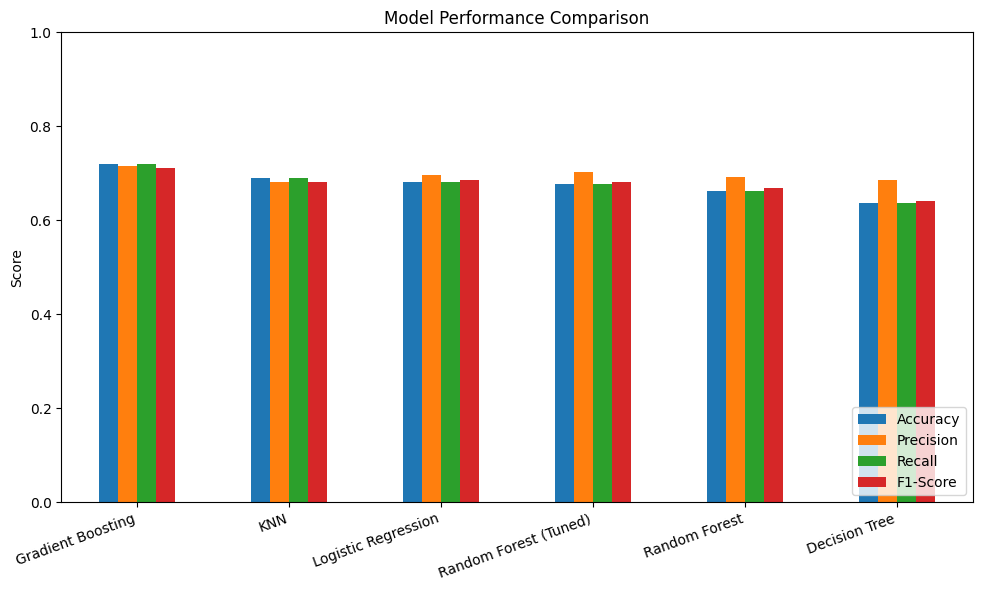

In [45]:
fig, ax = plt.subplots(figsize=(10,6))
results_df[['Accuracy', 'Precision', 'Recall', 'F1-Score']].plot(kind='bar', ax=ax)
ax.set_title('Model Performance Comparison')
ax.set_ylabel('Score')
ax.set_ylim(0, 1)
ax.legend(loc='lower right')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

Best Performing Model: Gradient Boosting


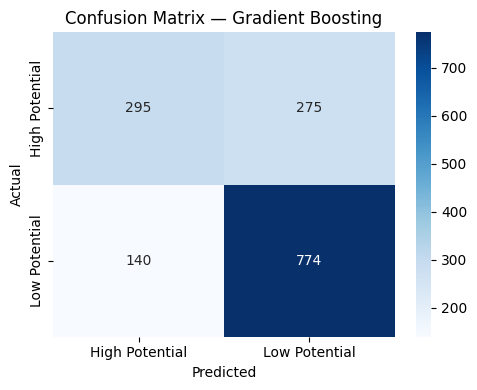

In [46]:
scaled_models = {'Logistic Regression', 'KNN'}
best_model_name = results_df['Accuracy'].idxmax()
best_model = trained_models[best_model_name]
X_eval_best = X_test_scaled if best_model_name in scaled_models else X_test

best_preds = best_model.predict(X_eval_best)

print(f"Best Performing Model: {best_model_name}")

cm = confusion_matrix(y_test, best_preds)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title(f'Confusion Matrix — {best_model_name}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

## **13. Feature Importance**

Feature importance analysis identifies which lead attributes are most useful for
distinguishing High Potential from Low Potential leads. The Random Forest model is
used since it naturally computes importance scores.

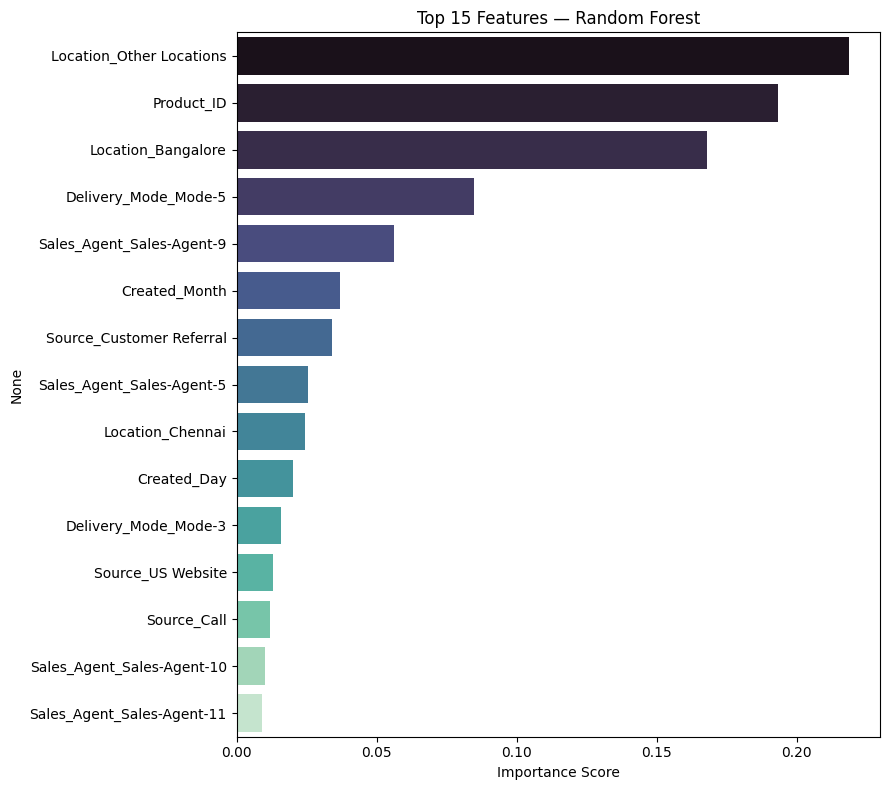

,0
Location_Other Locations,0.218780
Product_ID,0.193161
Location_Bangalore,0.168021
Delivery_Mode_Mode-5,0.084611
Sales_Agent_Sales-Agent-9,0.056243
Created_Month,0.036793
Source_Customer Referral,0.034224
Sales_Agent_Sales-Agent-5,0.025583
Location_Chennai,0.024352
Created_Day,0.020032


In [47]:
rf_model = trained_models['Random Forest']
importances = pd.Series(rf_model.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False)

plt.figure(figsize=(9,8))
sns.barplot(x=importances.head(15).values, y=importances.head(15).index, palette='mako')
plt.title('Top 15 Features — Random Forest')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

importances.head(15)

## **14. Business Insights**

**1. Data-Driven Lead Prioritization:**<br>
The model gives sales agents a way to see which incoming leads are High Potential
before manual review, letting effort be focused where conversion is most likely.<br><br>

**2. Channel Effectiveness:**<br>
Lead source and delivery mode carry meaningful predictive weight, showing that some
acquisition channels consistently produce higher-quality leads than others.<br><br>

**3. Agent and Location Patterns:**<br>
Sales agent and location features contribute to the prediction, suggesting that
regional demand and agent handling both influence conversion likelihood.<br><br>

**4. From Manual to ML-Assisted Categorization:**<br>
The current manual categorization process only informs post-analysis; an ML model
that scores leads at capture time moves that value earlier, directly into the sales
workflow.

## **15. Challenges Faced**

**1. No Ready-Made Target Column:**<br>
The raw table has no `Lead_Category` field — it had to be derived from `Status`,
which required inspecting the real status values and building/validating a mapping
rather than assuming one.<br><br>

**2. Missing Values Across Several Columns:**<br>
`Product_ID`, `Source`, `Mobile`, `Sales_Agent`, and `Location` all had missing
entries that needed column-appropriate handling rather than a single blanket
strategy.<br><br>

**3. High-Cardinality Categorical Features:**<br>
`Sales_Agent` and `Location` have many unique values, which inflates the feature
space after one-hot encoding and can be revisited later with grouping or target
encoding if needed.<br><br>

**4. Secure Handling of Database Credentials:**<br>
The dataset lives on a remote MySQL server, so credentials had to be entered at
runtime (`getpass`) rather than hard-coded into the notebook.

**5. Silent Target Leakage from a Mismatched Mapping (found during review):**<br>
The first version of the `Status` → `Lead_Category` mapping used placeholder keys
that didn't exactly match the real (case-sensitive) status strings in the data. As
a result every lead silently collapsed into a single `Low Potential` class, which
crashed Logistic Regression and Gradient Boosting training (`only one class in the
data`) and produced a meaningless 100% accuracy for the other models. The fix was
to inspect `df['Status'].unique()` directly and build the mapping from the exact
strings, then re-verify `df['Lead_Category'].value_counts()` shows a real two-class
split before modelling.

## **16. Final Conclusion**

**1. Project Objective:**<br>
The objective was to build a Machine Learning model that pre-categorizes FicZon's
leads as High Potential or Low Potential, replacing a purely manual, post-hoc
categorization process.<br><br>

**2. Exploratory Data Analysis:**<br>
EDA on 7,422 leads surfaced clear differences in volume across lead sources, sales
agents, locations, and delivery modes, and showed the status breakdown the target
variable is built from.<br><br>

**3. Modelling:**<br>
Five classification models were trained and compared, with Random Forest tuned
further via `GridSearchCV`. Model comparison, a confusion matrix, and feature
importance analysis identified the best-performing model and the attributes driving
its predictions.<br><br>

**4. Business Impact:**<br>
The resulting model gives FicZon a way to score lead quality automatically at the
point of capture, supporting the goal of increasing sales effectiveness.<br><br>

**5. Next Steps:**<br>
Validate the `Status` → `Lead_Category` mapping with FicZon's sales team, monitor
model performance on new leads over time, and consider retraining periodically as
lead patterns evolve.

# **17. Project Links**

The following links provide access to the complete project resources, including the source code, dataset, and supporting documentation.

## **1. GitHub Repository**
Access the complete source code, Jupyter Notebook, README, and project files.

🔗 **GitHub Repository:** https://github.com/Sameekshagithub/PRCL-0019-Sales-Effectiveness-Lead-Category-Prediction-Using-Machine-Learning.git


---

## **2. Google Drive**
Access the PPT and REPORT.

🔗 **Google Drive:** https://drive.google.com/drive/folders/1VE1wgDlXmQN1fXl-I-5Ymj2P8KUPEK49?usp=drive_link


---

